Import Libraries


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
import os
print(os.listdir())

['.config', 'Technological-Products-Sample-Data.xlsx', 'sample_data']


Load Dataset

In [18]:
df = pd.read_excel(
    "Technological-Products-Sample-Data.xlsx",
    sheet_name="Tech Products",
    header=5
)

df.head()

,Unnamed: 0,Brand,Device,Model,Country of Origin,Date of Release,Price (USD)
0,NaN,Apple,iPhone,13 Pro Max,United States,2021-09-24,1099
1,NaN,Samsung,Galaxy,S21 Ultra,South Korea,2021-01-29,1199
2,NaN,Google,Pixel,6 Pro,United States,2021-10-19,899
3,NaN,Sony,PlayStation,5,Japan,2020-11-12,499
4,NaN,Microsoft,Surface,Laptop 4,United States,2021-04-15,999


Dataset Overview

In [19]:
df.shape
df.columns
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   Unnamed: 0         0 non-null      float64       
 1   Brand              30 non-null     object        
 2   Device             30 non-null     object        
 3   Model              30 non-null     object        
 4   Country of Origin  30 non-null     object        
 5   Date of Release    30 non-null     datetime64[ns]
 6   Price (USD)        30 non-null     int64         
dtypes: datetime64[ns](1), float64(1), int64(1), object(4)
memory usage: 1.8+ KB


,Unnamed: 0,Date of Release,Price (USD)
count,0.0,30,30.000000
mean,NaN,2021-03-21 04:48:00,1056.000000
min,NaN,2020-07-22 00:00:00,229.000000
25%,NaN,2021-01-28 06:00:00,711.500000
50%,NaN,2021-03-17 12:00:00,999.000000
75%,NaN,2021-05-19 06:00:00,1336.500000
max,NaN,2021-10-26 00:00:00,1999.000000
std,NaN,NaN,469.880029


Data Cleaning

In [20]:
df = df.drop(columns=["Unnamed: 0"])
df.isnull().sum()
df.duplicated().sum()

np.int64(0)

Data Transformation

In [22]:
df['Date of Release'] = pd.to_datetime(df['Date of Release'])
df['Release Year'] = df['Date of Release'].dt.year

Outlier Detection

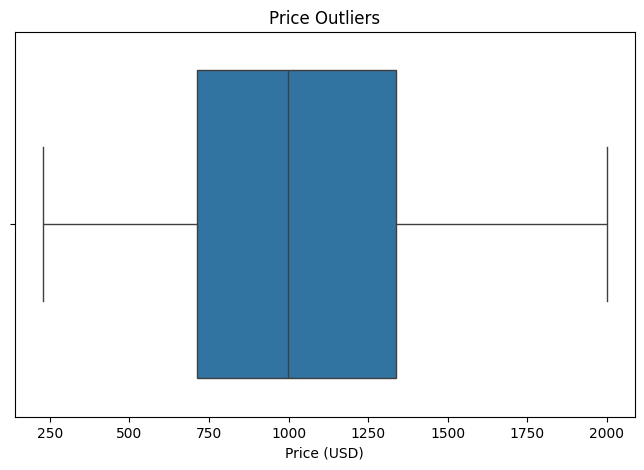

In [23]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['Price (USD)'])
plt.title("Price Outliers")
plt.show()

Data Visualization

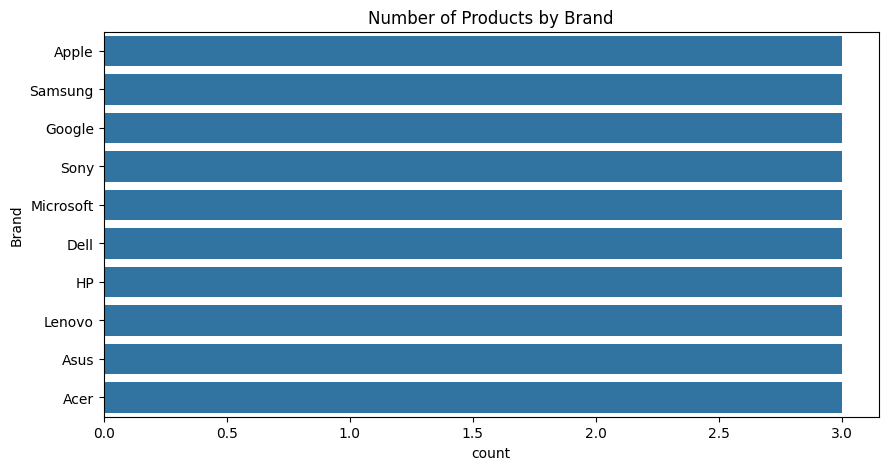

In [24]:
#Visualization 1: Products by Brand

plt.figure(figsize=(10,5))

sns.countplot(
    y='Brand',
    data=df,
    order=df['Brand'].value_counts().index
)

plt.title("Number of Products by Brand")
plt.show()


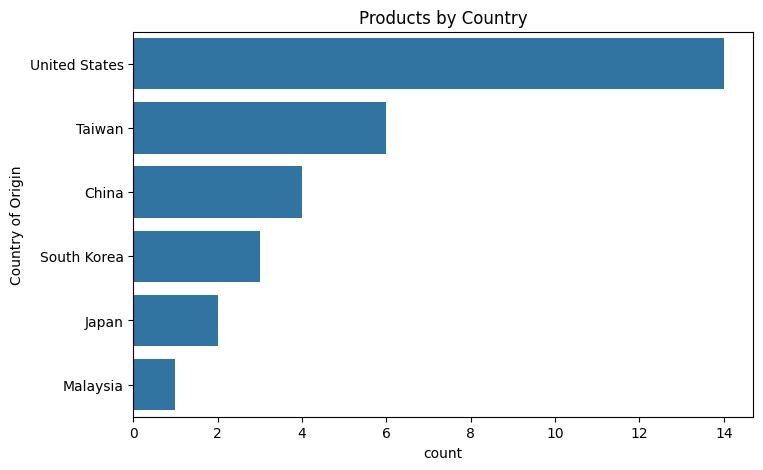

In [29]:
#Visualization 2: Products by Country

plt.figure(figsize=(8,5))

sns.countplot(
    y='Country of Origin',
    data=df,
    order=df['Country of Origin'].value_counts().index
)

plt.title("Products by Country")
plt.show()

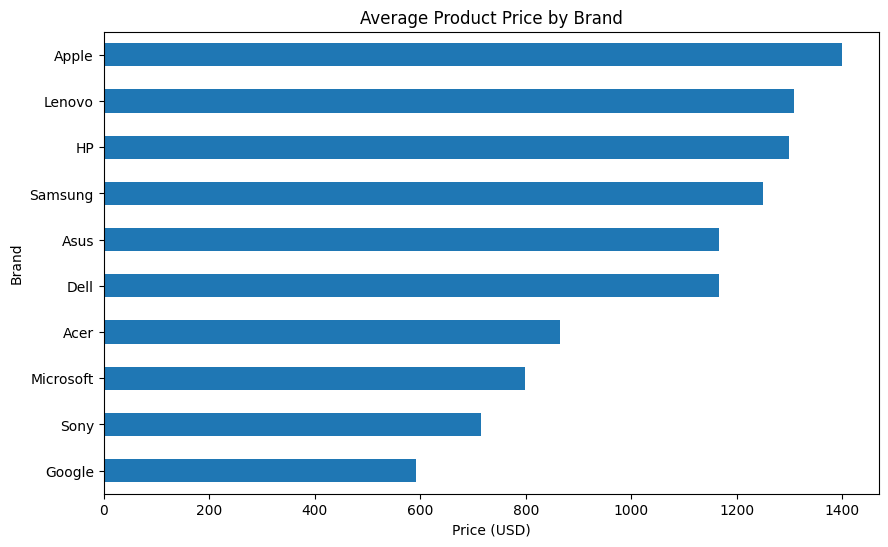

In [26]:
#Visualization 3: Average Product Price by Brand

brand_price = df.groupby('Brand')['Price (USD)'].mean().sort_values()

brand_price.plot(
    kind='barh',
    figsize=(10,6)
)

plt.title("Average Product Price by Brand")
plt.xlabel("Price (USD)")
plt.show()

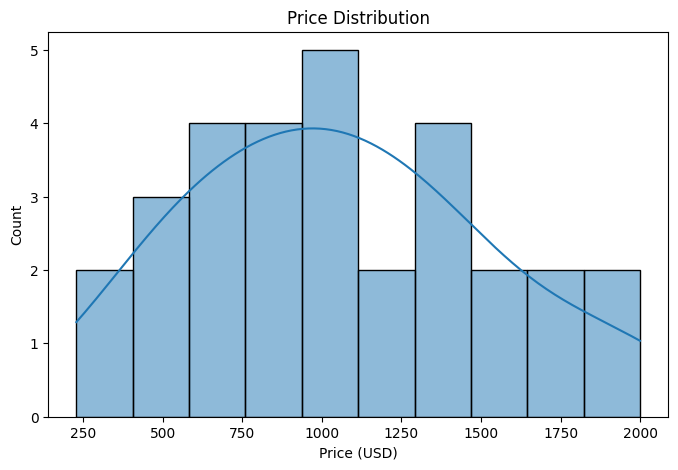

In [27]:
#Visualization 4: Price Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    df['Price (USD)'],
    bins=10,
    kde=True
)

plt.title("Price Distribution")
plt.show()

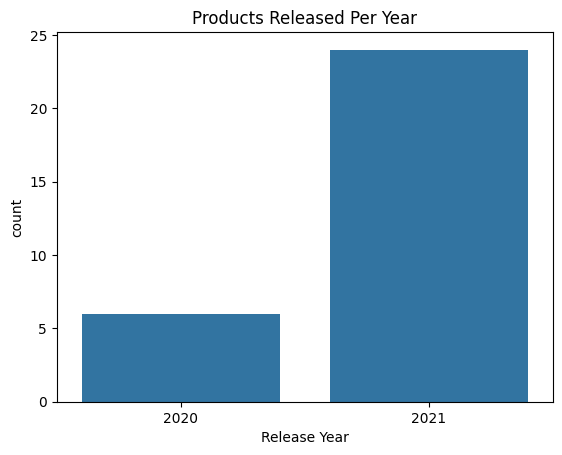

In [28]:
#Visualization 5: Release Year Trend

sns.countplot(
    x='Release Year',
    data=df
)

plt.title("Products Released Per Year")
plt.show()